In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import LiqFunDobPen as lf
import ParametersLiq as lp
import time 
from IPython.display import clear_output

In [9]:
df = pd.read_csv("double_pendulum_dataset.csv") # Charge the csv(DATA)
# We have to turn it into an array
data = df.values
# Separate inputs and outputs
X = data[:, :4] # Inputs
Y = data[:, 4:] # Outputs

In [10]:
# Computation of the mean and std 
X_mean, X_std = lf.compute_stats(X)
Y_mean, Y_std = lf.compute_stats(Y)
# Normalization
X_norm = lf.norm(X, X_mean, X_std)
Y_norm = lf.norm(Y, Y_mean, Y_std)

In [11]:
# We need time sequences
X_seq = []
Y_seq = []
for i in range(len(X)-lp.seq_len):
    X_seq.append(X_norm[i:i+lp.seq_len])
    Y_seq.append(Y_norm[i:i+lp.seq_len])
X_seq = np.array(X_seq)
Y_seq = np.array(Y_seq)

In [12]:
net = lf.LiquidNetwork(
    input_size=X.shape[1],
    hidden_size=lp.hidden_size,
    output_size=Y.shape[1]
)

# ===== MOMENTOS ADAM =====
m_W_in = np.zeros_like(net.W_in)
m_W_rec = np.zeros_like(net.W_rec)
m_W_out = np.zeros_like(net.W_out)
m_bias = np.zeros_like(net.bias)
m_b_out = np.zeros_like(net.bias_out)

v_W_in = np.zeros_like(net.W_in)
v_W_rec = np.zeros_like(net.W_rec)
v_W_out = np.zeros_like(net.W_out)
v_bias = np.zeros_like(net.bias)
v_b_out = np.zeros_like(net.bias_out)

t_adam = 0

dt = 0.01
rollout_steps = 2
tbptt_steps = 15
E0 = lf.energy(X_seq[i, 0])

# ===== TRAINING =====
for epoch in range(lp.epochs):

    start = time.time()
    total_loss = 0
    lr = lp.initial_lr 

    indices = np.random.permutation(len(X_seq))

    for i in indices[:10000]:

        # ===== ACUMULADORES DE GRAD =====
        grad_W_in_total = np.zeros_like(net.W_in)
        grad_W_rec_total = np.zeros_like(net.W_rec)
        grad_W_out_total = np.zeros_like(net.W_out)
        grad_bias_total = np.zeros_like(net.bias)
        grad_b_out_total = np.zeros_like(net.bias_out)

        seq_len = len(X_seq[i])

        loss = 0

        for t0 in range(0, seq_len - rollout_steps, tbptt_steps):

            if t0 == 0:
                net.reset()

            states = []
            outputs = []
            inputs = []
            targets = []

            rollout_states = None
            rollout_inputs = None

            # ===== FORWARD =====
            for t in range(t0, min(t0 + tbptt_steps, seq_len - rollout_steps)):

                x_t = X_seq[i, t]
                y_t = Y_seq[i, t]
                


                y_pred = net.step(x_t)
                

                # multi-step opcional
                #if t + 5 < seq_len:
                    #y5 = net.step(X_seq[i, t+4])
                    #loss += 0.02 * lf.mse_loss(y5, Y_seq[i, t+4])

                loss += 1.5 * lf.mse_loss(y_pred, y_t)

                # ===== ROLLOUT =====
                if t % 15 == 0:
                    rollout_states = []
                    rollout_inputs = []

                    x = x_t.copy()
                    saved_state = net.state.copy()
                    

                    for k in range(rollout_steps):

                        y_roll = net.step(x, dt)

                        rollout_states.append(net.state.copy())
                        rollout_inputs.append(x.copy())

                        theta = x[:2]
                        omega = x[2:]
                        alpha = y_roll
                        omega_half = omega + 0.5 * dt * alpha
                        theta = theta + dt * omega_half
                        omega = omega_half + 0.5 * dt * alpha

                        x_new = np.empty_like(x)
                        x_new[:2] = theta
                        x_new[2:] = omega
                        x = x_new
                
                    x_real = X_seq[i, t + rollout_steps]
                    loss += 0.05 * lf.mse_loss(x, x_real)
                    E_pred = lf.energy(x)
                    E_real = lf.energy(X_seq[i, t + rollout_steps])
                    
                    loss += 0.0005 * (E_pred - E0)**2
                    loss += 0.0005 * np.sum(y_pred**2)
                    loss += 0.0003 * np.sum(np.maximum(0, y_pred * x_t[2:]) )  # velocidad
                    loss += 0.0005 * np.sum(np.maximum(0, y_pred * x_t[:2]))   # ángulo
                    loss += 0.0005 * np.sum(y_pred * x_t[:2])


                    net.state = saved_state

                # ✅ SIEMPRE guardar (fuera del if)
                states.append(net.state.copy())
                outputs.append(y_pred)
                inputs.append(x_t)
                targets.append(y_t)
                
            num_steps = len(states)
            loss /= (num_steps + 1e-6)


            # ===== BACKWARD =====
            grad_W_in = np.zeros_like(net.W_in)
            grad_W_rec = np.zeros_like(net.W_rec)
            grad_W_out = np.zeros_like(net.W_out)
            grad_bias = np.zeros_like(net.bias)
            grad_b_out = np.zeros_like(net.bias_out)

            grad_state_next = np.zeros(net.hidden_size)
            grad_state_roll = np.zeros(net.hidden_size)

            # ===== ROLLOUT BACKWARD =====
            #if rollout_states is not None:
                #for k in reversed(range(rollout_steps)):

                    #state_k = rollout_states[k]
                    #input_k = rollout_inputs[k]

                    #grad_x = 0.05 * (x - x_real)

                    #grad_theta = grad_x[:2]
                    #grad_omega = grad_x[2:]

                    #grad_y = grad_omega * dt + grad_theta * (dt ** 2)

                    #grad_W_out += grad_y[:, None] * state_k[None, :]
                    #grad_b_out += grad_y

                    #grad_state = net.W_out.T @ grad_y + grad_state_roll

                    #z = net.W_in @ input_k + net.W_rec @ state_k + net.bias

                    #tanh_z = np.tanh(z)
                    #sin_z = np.sin(z)
                    #cos_z = np.cos(z)

                    #dact = (1 - tanh_z**2) + 0.3 * cos_z

                    #grad = dact * grad_state

                    #grad_W_rec += grad[:, None] * state_k[None, :]
                    #grad_W_in += grad[:, None] * input_k[None, :]
                    #grad_bias += grad

                    #grad_state_roll = net.W_rec.T @ grad

            # ===== BPTT =====
            for t in reversed(range(len(states))):

                state_t = states[t]
                input_t = inputs[t]
                y_pred = outputs[t]
                y_true = targets[t]

                grad_y = lf.mse_grad(y_pred, y_true)

                grad_W_out += grad_y[:, None] * state_t[None, :]
                grad_b_out += grad_y

                grad_state = net.W_out.T @ grad_y + grad_state_next

                z = net.W_in @ input_t + net.W_rec @ state_t + net.bias
                tanh_z = np.tanh(z)

                dtanh = 1 - tanh_z**2

                grad = np.clip(dtanh * grad_state,-5, 5)

                grad_W_rec += grad[:, None] * state_t[None, :]
                grad_W_in += grad[:, None] * input_t[None, :]
                grad_bias += grad

                grad_state_next = net.W_rec.T @ grad * dt

            # ===== ACUMULAR GRADIENTES =====
            grad_W_in_total += grad_W_in
            grad_W_rec_total += grad_W_rec
            grad_W_out_total += grad_W_out
            grad_bias_total += grad_bias
            grad_b_out_total += grad_b_out

        # ===== CLIPPING GLOBAL =====
        total_norm = np.sqrt(
            np.sum(grad_W_in_total**2) +
            np.sum(grad_W_rec_total**2) +
            np.sum(grad_W_out_total**2) +
            np.sum(grad_bias_total**2) +
            np.sum(grad_b_out_total**2)
        )

        scale = min(1.0, 1.0 / (total_norm + 1e-6))

        grad_W_in_total *= scale
        grad_W_rec_total *= scale
        grad_W_out_total *= scale
        grad_bias_total *= scale
        grad_b_out_total *= scale

        # ===== ADAM =====
        t_adam += 1

        

        m_W_in, v_W_in = lf.adam_update(net.W_in, grad_W_in_total, m_W_in, v_W_in, t_adam, lr)
        m_W_rec, v_W_rec = lf.adam_update(net.W_rec, grad_W_rec_total, m_W_rec, v_W_rec, t_adam, lr)
        m_W_out, v_W_out = lf.adam_update(net.W_out, grad_W_out_total, m_W_out, v_W_out, t_adam, lr)
        m_bias, v_bias = lf.adam_update(net.bias, grad_bias_total, m_bias, v_bias, t_adam, lr)
        m_b_out, v_b_out = lf.adam_update(net.bias_out, grad_b_out_total, m_b_out, v_b_out, t_adam, lr)
        total_loss += loss

    total_loss /= len(X_seq)

    end = time.time()

    print(f"Epoch {epoch}, Loss: {total_loss:.4f}, Time: {end - start:.2f}s")
    

Epoch 0, Loss: 1.7210, Time: 108.24s
Epoch 1, Loss: 1.6811, Time: 57.34s
Epoch 2, Loss: 1.6746, Time: 56.91s
Epoch 3, Loss: 1.6378, Time: 54.24s
Epoch 4, Loss: 1.5978, Time: 57.23s
Epoch 5, Loss: 1.5755, Time: 57.02s
Epoch 6, Loss: 1.5647, Time: 58.12s
Epoch 7, Loss: 1.5678, Time: 59.20s
Epoch 8, Loss: 1.5274, Time: 59.78s
Epoch 9, Loss: 1.5164, Time: 97.54s
Epoch 10, Loss: 1.4791, Time: 216.18s
Epoch 11, Loss: 1.4750, Time: 226.40s
Epoch 12, Loss: 1.4377, Time: 220.09s
Epoch 13, Loss: 1.4079, Time: 74.03s
Epoch 14, Loss: 1.3866, Time: 58.41s
Epoch 15, Loss: 1.3879, Time: 57.45s
Epoch 16, Loss: 1.3894, Time: 64.34s
Epoch 17, Loss: 1.4102, Time: 59.63s
Epoch 18, Loss: 1.4100, Time: 57.64s
Epoch 19, Loss: 1.3925, Time: 76.79s
Epoch 20, Loss: 1.3761, Time: 90.21s
Epoch 21, Loss: 1.3665, Time: 58.60s
Epoch 22, Loss: 1.3493, Time: 56.05s
Epoch 23, Loss: 1.3628, Time: 197.84s
Epoch 24, Loss: 1.3419, Time: 96.72s
Epoch 25, Loss: 1.3282, Time: 96.00s
Epoch 26, Loss: 1.3288, Time: 83.88s
Epoch 

In [13]:
x0 = X_norm[0]
traj = lf.simulate(net, x0, steps = 300)

Text(0.5, 1.0, 'Simulación red líquida del péndulo doble')

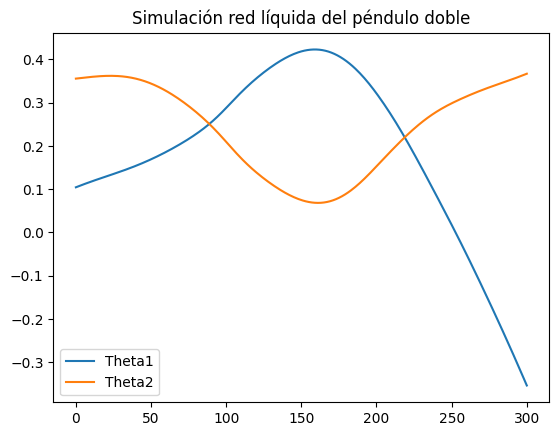

In [14]:
plt.plot(traj[:, 0], label="Theta1")
plt.plot(traj[:, 1], label="Theta2")
plt.legend()
plt.title("Simulación red líquida del péndulo doble")